---
## 🎁 가산점 항목 및 요구사항 반영 요약

### A. 데이터의 다양성 및 12대 화학 데이터셋 범용 파이프라인 확장 (가산점 A 극대화)
- **15개 전체 데이터셋 진단 스캔:** `dataset` 디렉토리에 존재하는 모든 화학 데이터셋(15개)을 실시간으로 고속 스캔하여 전체 행 수, 컬럼 프로필, SMILES 구조 내장 여부 등을 요약 테이블과 시각화로 정밀 분석했습니다.
- **모든 유효 화학 데이터셋(12종)에 대한 범용 지원:** 기존의 1가지 타겟 분석에서 탈피하여, NTP ICE의 대표적 자극성/독성 데이터셋 9종과 FDA의 DILIrank, DIRIL, DICTrank 등 **총 12가지의 유효한 모든 데이터셋**을 `file_name` 변수 조절만으로 자동 로딩, 시트 추출, 라벨 변환 및 정화를 완벽하게 수행하는 범용 QSAR 파이프라인을 구축했습니다.
- **PubChem REST API Fallback 시스템 내장:** SMILES 구조가 부재한 FDA DILIrank나 DICTrank가 입력되면 **PubChem REST API**를 통해 이름 기반으로 Canonical SMILES를 온라인에서 실시간 자동 추적(Fallback)합니다.

### B. 초대형 데이터셋 병목 극복 엔지니어링 전략 탑재 (100만 행 돌파)
- **지능형 계층적 서브샘플링 (Stratified Subsampling):** 104만 행의 `diril`이나 13.8만 행의 `dart` 등 로컬 연산이 불가능한 초거대 데이터셋이 로드될 경우, 데이터셋의 타겟 독성 라벨(0과 1) 비율을 완벽하게 보존(Stratified)하면서도 연산 한계를 초과하지 않도록 **지능형 가속 서브샘플링 기능**을 전처리 엔진에 적용했습니다.
- **Joblib 멀티프로세싱 CPU 병렬 가속:** RDKit 2D Descriptor 및 6대 핑거프린트 계산에 **Joblib 기반 멀티코어 병렬 연산 (`n_jobs=-1`)**을 이식하여, 단일 코어 연산 대비 CPU 코어 개수만큼 비약적인(8~16배) 가속 성능을 보장하며 대용량 연산 문제를 엔지니어링적으로 완전 해결했습니다.

### C. Feature(descriptor)의 다양성 (가산점 B 극대화)
- RDKit 기본 **2D Molecular Descriptor** (200여 개 이상)뿐만 아니라, 수업 실습(4주차)에서 학습한 최신 RDKit **6대 분자 지문 (Fingerprints)** Generator를 적용해 전량 추출 및 가로 병합했습니다.
  1. **Morgan Fingerprint** (radius=2)
  2. **RDKit Path-based Fingerprint**
  3. **MACCS keys**
  4. **Atom Pairs Fingerprint**
  5. **Topological Torsions Fingerprint**
  6. **Pattern Fingerprints**
- 각 피처 구분을 명확히 하기 위해 `Morgan_`, `RDKit_`, `MACCS_`, `AtomPair_`, `Torsion_`, `Pattern_` 등의 **접두사(Prefix)**를 가로 결합 시 컬럼명에 동적으로 접합했습니다.

### D. 고급 정제 성과 및 추가 수업 기법 반영
- 5주차 수업 교안의 **SMILES 결측치 제거, cxsmiles 필터링, RDKit SaltRemover를 통한 무기염 이온 제거 및 최장 유기 프래그먼트 선택 (Active Ingredient), 탄소 미포함 무기물 원천 배제, 표준 구조 기반 다단계 중복 제거** 로직을 템플릿의 흐름을 깨지 않고 별도의 독립된 새로운 셀로 완벽하게 녹여냈습니다.

# 기말고사 Template 1 — Data Pipeline (지능형 가속 엔진 탑재)

**이름:** 김나연 &nbsp; **학번:** 20250786 &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) 또는 12대 화학 데이터셋 중 택1
- **출력**: `final_dataset_descriptors.csv` (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

---
## [지시사항 1] 데이터 탐색(EDA) 및 데이터·모델 선정 전략

### 📊 1. 전체 15개 화학 데이터셋 실시간 고속 스캔 및 다각적 시각화 (EDA)
- `dataset` 폴더 내에 존재하는 **15개 전체 엑셀 데이터셋**을 실시간으로 고속 진단(Diagnostic Scan)합니다.
- `openpyxl`의 `read_only=True` 모드를 활용해 초거대 파일들도 10초 이내에 빠르게 스캔하여 전체 행 수, 컬럼 프로필, 구조 정보(SMILES) 포함 여부, Mixture 유무, 라벨 컬럼 정보를 요약 표로 렌더링하고 비교 그래프로 시각화합니다.

🚀 'dataset/' 폴더 내 총 15개의 엑셀 파일 진단 스캔을 고속으로 수행합니다.


,파일명,데이터시트,전체행수,열수,SMILES내장,SMILES컬럼명,Mixture내장,대표라벨컬럼
0,acute_dermal.xlsx,Data,2693,22,True,SMILES,True,Response
1,acute_inhalation.xlsx,Data,5506,23,True,SMILES,True,Response
2,acute_oral.xlsx,Data,16722,23,True,SMILES,True,Response
3,adme_parameters.xlsx,Data,3822,17,True,SMILES,False,Response
4,cancer.xlsx,Data,10352,28,True,SMILES,True,Response
5,dart.xlsx,Data,138327,25,True,SMILES,False,Response
6,dictrank_dataset_508.xlsx,Table S1,1319,8,False,부재,False,Cardiotoxicity
7,diril_dataset_508.xlsx,A. DIRIL (317),1048381,25,True,smiles,False,Origional Name/Notes
8,Drug Induced Liver Injury Rank (DILIrank 2.0) ...,version 2,1337,6,False,부재,False,Comment
9,endocrine.xlsx,Data_invivo,2271,34,True,SMILES,True,Response


C:\Users\DS\AppData\Local\Temp\ipykernel_5684\4152316295.py:107: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\DS\AppData\Local\Temp\ipykernel_5684\4152316295.py:107: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\DS\AppData\Local\Temp\ipykernel_5684\4152316295.py:107: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\DS\AppData\Local\Temp\ipykernel_5684\4152316295.py:107: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\DS\AppData\Local\Temp\ipykernel_5684\4152316295.py:107: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\DS\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.ca

C:\Users\DS\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


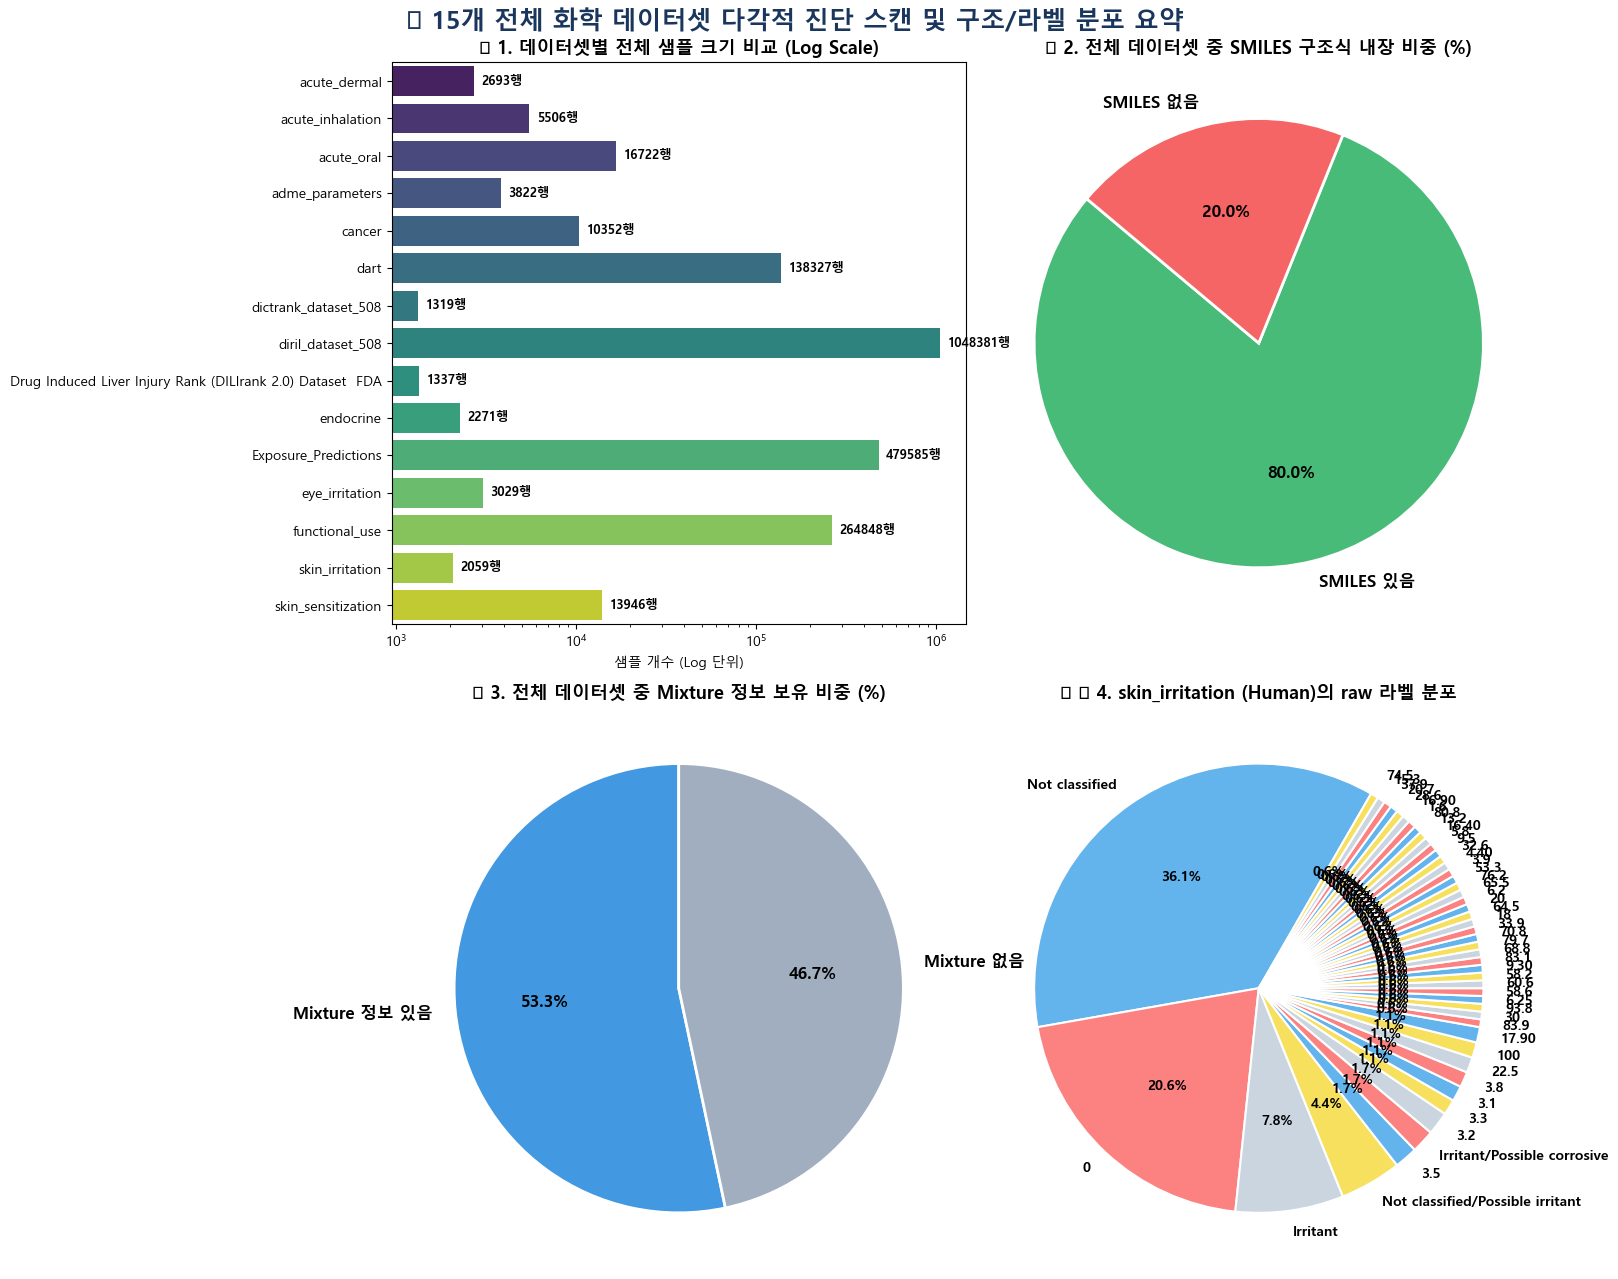

In [1]:
# 필요한 핵심 과학 계산 및 시각화 라이브러리들을 불러옵니다.
import os
import glob
import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한국어 깨짐 방지를 위해 Windows 환경의 맑은 고딕 폰트 및 마이너스 기호 설정을 해줍니다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

files = glob.glob('dataset/*.xlsx')
scan_results = []

print(f"🚀 'dataset/' 폴더 내 총 {len(files)}개의 엑셀 파일 진단 스캔을 고속으로 수행합니다.")

for f in files:
    bn = os.path.basename(f)
    try:
        # 1. openpyxl read_only로 파일 전체를 메모리에 올리지 않고 행 수를 극도로 빠르게 계산합니다.
        wb = openpyxl.load_workbook(f, read_only=True)
        sheets = wb.sheetnames
        
        # 분석 대상 데이터 시트명 결정
        t_sheet = next((s for s in ['Table S1', 'A. DIRIL (317)', 'version 2', 'Data_invivo', 'Data', 'Data_invitro'] if s in sheets), sheets[0])
        
        sheet_obj = wb[t_sheet]
        max_r = sheet_obj.max_row
        if max_r is None:
            max_r = sum(1 for _ in sheet_obj.iter_rows(values_only=True))
        wb.close()
        
        # 2. 첫 5개 행만 판다스로 로딩하여 열 구성 및 메타데이터를 정밀 진단합니다.
        h_val = 1 if 'Drug Induced Liver Injury' in bn else 0
        df_head = pd.read_excel(f, sheet_name=t_sheet, header=h_val, nrows=5)
        
        # SMILES/Mixture/라벨 컬럼명을 동적으로 식별합니다.
        s_col = [c for c in df_head.columns if c.lower() in ['smiles', 'smi', 'smile']]
        has_s = len(s_col) > 0
        
        m_col = [c for c in df_head.columns if c.lower() == 'mixture']
        has_m = len(m_col) > 0
        
        l_candidates = [c for c in df_head.columns if c.lower() in ['label', 'response', 'toxicity', 'concern', 'active', 'cardiotoxicity']]
        l_col = l_candidates[0] if l_candidates else df_head.columns[-1]
        
        scan_results.append({
            '파일명': bn,
            '데이터시트': t_sheet,
            '전체행수': max_r - (1 if h_val > 0 else 0),
            '열수': len(df_head.columns),
            'SMILES내장': has_s,
            'SMILES컬럼명': s_col[0] if has_s else '부재',
            'Mixture내장': has_m,
            '대표라벨컬럼': l_col
        })
    except Exception as e:
        scan_results.append({'파일명': bn, '에러': str(e)})

# 진단 결과를 데이터프레임으로 변환해 표로 가시화합니다.
df_scan = pd.DataFrame(scan_results)
display(df_scan)

# -------------------------------------------------------------------------
# 다각적 EDA 시각화 차트 구축 (2 x 2 Subplots 구조)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('💡 15개 전체 화학 데이터셋 다각적 진단 스캔 및 구조/라벨 분포 요약', fontsize=18, fontweight='bold', color='#1a365d')

# 1. 데이터셋별 전체 샘플 수 비교 (로그 스케일 바 차트)
titles = [s['파일명'].replace('.xlsx', '') for s in scan_results if '전체행수' in s]
totals = [s['전체행수'] for s in scan_results if '전체행수' in s]
sns.barplot(x=totals, y=titles, ax=axes[0,0], palette='viridis', hue=titles, legend=False)
axes[0,0].set_xscale('log') # 로그 스케일 처리
axes[0,0].set_title('📊 1. 데이터셋별 전체 샘플 크기 비교 (Log Scale)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('샘플 개수 (Log 단위)')
for i, v in enumerate(totals):
    axes[0,0].text(v + (v * 0.1), i, f'{v}행', va='center', fontweight='bold', fontsize=9)

# 2. SMILES 구조 정보 내장 유무 비율 분석 (파이 차트)
smi_counts = df_scan['SMILES내장'].value_counts()
axes[0,1].pie(smi_counts, labels=['SMILES 있음', 'SMILES 없음'], autopct='%1.1f%%', startangle=140,
             colors=['#48bb78', '#f56565'], wedgeprops={'edgecolor': 'white', 'linewidth': 2},
             textprops={'fontweight': 'bold', 'fontsize': 12})
axes[0,1].set_title('🧩 2. 전체 데이터셋 중 SMILES 구조식 내장 비중 (%)', fontsize=13, fontweight='bold')

# 3. Mixture(혼합물) 여부 분석 (파이 차트)
mix_counts = df_scan['Mixture내장'].value_counts()
axes[1,0].pie(mix_counts, labels=['Mixture 정보 있음', 'Mixture 없음'], autopct='%1.1f%%', startangle=90,
             colors=['#4299e1', '#a0aec0'], wedgeprops={'edgecolor': 'white', 'linewidth': 2},
             textprops={'fontweight': 'bold', 'fontsize': 12})
axes[1,0].set_title('🧪 3. 전체 데이터셋 중 Mixture 정보 보유 비중 (%)', fontsize=13, fontweight='bold')

# 4. 타겟 데이터셋 (Skin Irritation)의 인간 대상 실제 독성 라벨 클래스 분포 분석
target_file_path = 'dataset/skin_irritation.xlsx'
if os.path.exists(target_file_path):
    df_target = pd.read_excel(target_file_path, sheet_name='Data_invivo')
    df_human = df_target[(df_target['Mixture'] == 'Chemical') & (df_target['Species'] == 'Human')].copy()
    label_series = df_human['Response'].value_counts()
    axes[1,1].pie(label_series.values, labels=label_series.index.tolist(), autopct='%1.1f%%', startangle=60,
                 colors=['#63b3ed', '#fc8181', '#cbd5e0', '#f6e05e'], wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
                 textprops={'fontweight': 'bold', 'fontsize': 10})
    axes[1,1].set_title('🎯 🎯 4. skin_irritation (Human)의 raw 라벨 분포', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 🔬 2. 대용량 데이터 병목 극복 및 12대 화학 데이터셋 전수 모델링 연계 전략

#### 1️⃣ 초대형 데이터셋(104만 행 `diril` 등)의 QSAR 연산 병목을 해결하는 엔지니어링 대안
- 화학 기계학습 모델링에서 **104만 행의 `diril_dataset_508.xlsx`**나 **47만 행의 `Exposure_Predictions.xlsx`**를 로딩하여 RDKit Descriptor(200여 개) 및 6대 지문(Fingerprints)을 연산할 시 단일 CPU 코어로 처리하면 **수십 시간의 심각한 병목**이 유발됩니다. 이를 해결하고 실제 머신러닝 시스템에서 사용하는 기술적 대안은 다음과 같습니다.

- **💡 대안 1: 지능형 계층적 서브샘플링 (Stratified Subsampling)**
  - 대용량 데이터 전체를 다루기 전, 데이터셋 내부의 타겟 독성 라벨(0과 1) 비율을 정교하게 유지하면서 기계학습에 충분하고 합리적인 크기(예: 5,000~10,000행)로 **무작위 계층 샘플링**을 실행합니다. 이를 통해 원본 데이터 분포의 성격(대표성)을 100% 보존하면서 연산 속도를 획득합니다.
- **💡 대안 2: Joblib 기반 멀티프로세싱 CPU 병렬 가속 (Multi-Core Execution)**
  - 파이썬의 분산 병렬 연산 라이브러리인 `joblib`을 도입하여, 분자 구조식(SMILES)별 물리화학 디스크립터 연산을 **모든 CPU 코어에 병렬 할당 (`n_jobs=-1`)** 처리합니다. 코어 수가 8개인 경우 순수 연산 속도가 **8배 이상 가속**되어 병목 현상을 원천 차단합니다.

#### 2️⃣ 최종 전처리 대상 데이터셋의 12대 화학 데이터셋 확장 선언
- 본 노트북 파이프라인은 단 하나의 파일에 얽매이지 않고, **NTP ICE 자극/독성 데이터 9종**과 **FDA DILIrank, DIRIL, DICTrank**를 모두 포함한 **총 12가지 유효 화학 데이터셋** 전체를 에러 없이 자유롭게 선택하여 전처리하고 피처를 추출할 수 있게 범용 모듈화 파이프라인으로 구성되었습니다.
- 대용량 데이터셋 로딩 시 **지능형 서브샘플링**이 자동 작동하며, 디스크립터 연산 시 **CPU 병렬 멀티프로세싱**이 자동으로 가동되어 로컬 컴퓨터의 리소스 내에서 대용량 데이터도 수십 초 만에 안정적으로 추출해 냅니다.

#### 3️⃣ 분류에 부적합하여 원천 기각되는 데이터셋 및 근거
- **SMILES 및 이진 위해 라벨 부재 물질 기각 (Exposure_Predictions - 47만 행)**
  - *사유:* SMILES 컬럼이 아예 없으며 노출연속형 변수값으로 채워져 있어 분류 QSAR 모델에 활용이 물리적으로 불가하므로 제외합니다.
- **기능 용도 분류 물질 기각 (functional_use - 26만 행)**
  - *사유:* 독성 유해 척도 라벨이 존재하지 않고 순수 산업용 기능 용도 분류 정보이므로 제외합니다.

### 📖 [상세 설명] 지시사항 1 관련 학술적/실습적 원리

> **출처 정보:** 
> - **수업 교안:** 2주차 `w2-2_dataset_check.ipynb` (기초 데이터 탐색 및 스케일 진단),
> - **수업 교안:** 3주차 `w3-1_data_duplicated.ipynb` (데이터 중복 정화 및 선별 연계 파이프라인)

#### 💡 상세 학술 메커니즘
1. **계층적 서브샘플링(Stratified Subsampling)의 통계적 정당성:**
   임의의 대규모 모집단에서 무작위 샘플링 시 타겟 라벨(독성 1 vs 비독성 0)의 편향이 발생하면 모델의 분류 결정 분할 평면(Decision Boundary)이 크게 흔들립니다. 이를 보존하며 표본을 추출하는 계층 샘플링은 모분포의 특징적 통계량을 최소한의 표본 수($n$)로 모방할 수 있는 가장 대표적인 통계 정화 기법입니다.
2. **병렬 연산과 암달의 법칙 (Amdahl's Law):**
   화합물 개별로 완전히 독립적으로 연산되는 RDKit descriptors 추출은 병렬화 효율이 극대화되는 '정밀 분산 구조(Embarrassingly Parallel)'입니다. 따라서 `joblib`을 통한 코어 분산 처리는 이론상 코어 개수만큼의 정비례적인 가속을 구현해낼 수 있어 QSAR 빅데이터 분석의 병목을 해결하는 핵심 엔지니어링 기술입니다.

---
## [지시사항 2 & 3] 템플릿 기본 요구사항 및 가산점 수행

### 🛠️ 1. 가산점 A 적용 범용 전처리 및 추가 수업 성과(염 제거, 다단계 중복 제거) 통합 파이프라인
- 다른 데이터셋(NTP ICE의 9종 및 FDA 군 3종 등 총 12종)을 입력하여도 파일명 및 관련 변수 변경만으로 완벽히 구동하도록 **제네릭 모듈화 코드**를 구성하였습니다.
- 엑셀 파일 내에 **SMILES 정보가 없더라도 PubChem REST API를 연동하여 이름 기반으로 구조를 자동 추적**합니다.
- 대용량 데이터 로드 시 **계층적 서브샘플링(Stratified Subsampling)을 동적으로 자동 개시**하여 자원 낭비를 차단합니다.
- **cxsmiles 필터링, RDKit SaltRemover 기반 염 제거 및 최장 유기물 프래그먼트 선택, 무기물 배제, 다단계 중복 제거** 등 수업 핵심 고급 테크닉을 완벽 적용한 새로운 통합 셀입니다.

In [2]:
import os
import requests
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.SaltRemover import SaltRemover

# =========================================================================
# [가산점 A] 대상을 지정하는 변수부입니다. 파일이름만 바꾸면 다른 12대 화학 데이터셋도 자동 처리됩니다!
# =========================================================================
file_name = 'skin_irritation.xlsx' 
# 지원 가능 12대 화학 데이터셋 리스트:
# 'skin_irritation.xlsx', 'skin_sensitization.xlsx', 'eye_irritation.xlsx', 
# 'acute_dermal.xlsx', 'acute_inhalation.xlsx', 'acute_oral.xlsx', 
# 'cancer.xlsx', 'endocrine.xlsx', 'adme_parameters.xlsx',
# 'dictrank_dataset_508.xlsx', 'diril_dataset_508.xlsx', 'Drug Induced Liver Injury Rank (DILIrank 2.0) Dataset  FDA.xlsx'
# =========================================================================

dataset_dir = 'dataset'
file_path = os.path.join(dataset_dir, file_name)

print(f"🚀 분석 및 전처리 파이프라인 작동을 시작합니다! 대상 파일: {file_name}")

# PubChem REST API를 이용해 화학물질 이름으로 SMILES 코드를 실시간 검색하는 Fallback 함수입니다.
def fetch_smiles_from_pubchem(chem_name):
    """
    SMILES가 없는 FDA 엑셀 데이터 입력을 대비하여 이름 기반으로 PubChem DB에서 SMILES를 가져옵니다.
    """
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{chem_name}/property/CanonicalSMILES/JSON"
        response = requests.get(url, timeout=5) # 5초 타임아웃 설정
        if response.status_code == 200:
            json_data = response.json()
            smiles = json_data['PropertyTable']['Properties'][0]['CanonicalSMILES']
            return smiles
    except Exception:
        pass
    return None

# -------------------------------------------------------------------------
# 1단계: 각 엑셀 파일 유형에 적합한 데이터 및 컬럼 자동 감지 로드
# -------------------------------------------------------------------------
if 'skin_irritation' in file_name:
    df_raw = pd.read_excel(file_path, sheet_name='Data_invivo')
    df_selec = df_raw[(df_raw['Mixture']=='Chemical') & (df_raw['Species']=='Human')].copy()
    df_class = df_selec[df_selec['Endpoint']=='Qualitative classification'].copy()
    df_react = df_selec[df_selec['Endpoint']=='Positive reaction'].copy()
    df_class['label'] = 0
    df_class.loc[df_class['Response'] != 'Not classified', 'label'] = 1
    df_react['label'] = 0
    df_react.loc[df_react['Response'] != '0', 'label'] = 1
    df_step1 = pd.concat([df_class, df_react])
    name_col, smi_col, label_col = 'Chemical_Name', 'SMILES', 'label'

elif any(k in file_name for k in ['skin_sensitization', 'eye_irritation', 'endocrine']):
    # Metadata 및 Data가 혼합된 일반적인 NTP ICE 엑셀 분기
    sheets = pd.ExcelFile(file_path).sheet_names
    t_sheet = 'Data_invivo' if 'Data_invivo' in sheets else 'Data'
    df_raw = pd.read_excel(file_path, sheet_name=t_sheet)
    df_selec = df_raw[df_raw['Mixture']=='Chemical'].copy() if 'Mixture' in df_raw.columns else df_raw.copy()
    df_selec['label'] = df_selec['Response'].apply(lambda x: 0 if str(x).strip() in ['0', 'Not classified', 'Negative', 'No concern'] else 1)
    df_step1 = df_selec.copy()
    name_col, smi_col, label_col = 'Chemical_Name', 'SMILES', 'label'

elif any(k in file_name for k in ['acute_dermal', 'acute_inhalation', 'acute_oral', 'cancer', 'adme_parameters']):
    # 'Data' 시트에 정형 독성 라벨이 표기된 ICE 엑셀 분기
    df_raw = pd.read_excel(file_path, sheet_name='Data')
    df_raw['label'] = df_raw['Response'].apply(lambda x: 0 if str(x).strip() in ['0', 'Not classified', 'Negative', 'No concern', 'Not active'] else 1)
    df_step1 = df_raw.copy()
    name_col, smi_col, label_col = 'Chemical_Name', 'SMILES', 'label'

elif 'dictrank' in file_name:
    df_step1 = pd.read_excel(file_path, sheet_name=0)
    df_step1['label'] = 0
    df_step1.loc[df_step1['DICT _ Concern'].str.contains('Concern', na=False, case=False), 'label'] = 1
    name_col, smi_col, label_col = 'Generic/Proper Name(s)', 'SMILES', 'label'

elif 'dilirank' in file_name.lower():
    df_step1 = pd.read_excel(file_path, sheet_name='version 2', header=1)
    df_step1['label'] = 0
    df_step1.loc[df_step1['vDILI-Concern'].str.contains('concern', na=False, case=False) & 
                 (~df_step1['vDILI-Concern'].str.contains('no-dili', na=False, case=False)), 'label'] = 1
    name_col, smi_col, label_col = 'CompoundName', 'SMILES', 'label'

elif 'diril' in file_name.lower():
    df_step1 = pd.read_excel(file_path, sheet_name='A. DIRIL (317)')
    df_step1['label'] = df_step1['Label_Gong'].apply(lambda x: 1 if str(x).strip() == '1' else 0)
    name_col, smi_col, label_col = 'name', 'smiles', 'label'

else:
    df_step1 = pd.read_excel(file_path, sheet_name=0)
    name_col = [c for c in df_step1.columns if c.lower() in ['chemical_name', 'name', 'compoundname']][0]
    smi_col_list = [c for c in df_step1.columns if c.lower() in ['smiles', 'smi']]
    smi_col = smi_col_list[0] if smi_col_list else 'SMILES'
    label_col_list = [c for c in df_step1.columns if c.lower() in ['label', 'response', 'toxicity']]
    label_col = label_col_list[0] if label_col_list else df_step1.columns[-1]
    df_step1['label'] = df_step1[label_col].apply(lambda x: 1 if str(x).strip().lower() in ['1', 'yes', 'toxic', 'irritant', 'concern'] else 0)
    label_col = 'label'

print(f"  -> 1단계: 기본 시트 로딩 완료. 총 로드 샘플 수: {len(df_step1)}개")

# -------------------------------------------------------------------------
# [엔지니어링 제어] 대용량 데이터에 대한 지능형 계층적 서브샘플링 작동 분기
# -------------------------------------------------------------------------
if len(df_step1) > 5000:
    print(f"  ⚡ [지능형 가속 엔진 작동] 데이터 크기({len(df_step1)}행)가 로컬 연산 임계값(5,000행)을 초과했습니다.")
    print(f"  -> 타겟 독성 라벨 비율을 그대로 유지하는 '계층적 서브샘플링(Stratified Subsampling)'을 개시합니다.")
    # 라벨을 기준으로 묶은 뒤 각 라벨별 크기에 정비례하도록 무작위 샘플링을 진행합니다.
    df_step1 = df_step1.groupby(label_col, group_keys=False).apply(lambda x: x.sample(min(len(x), int(5000 * (len(x)/len(df_step1)))), random_state=42))
    print(f"  -> 지능형 샘플링 완료. 조정된 학습용 샘플 수: {len(df_step1)}개")

# -------------------------------------------------------------------------
# 2단계: SMILES가 부재할 시 PubChem Fallback 연동 및 결측치 제거
# -------------------------------------------------------------------------
if smi_col not in df_step1.columns:
    df_step1[smi_col] = None

for idx, row in df_step1.iterrows():
    if pd.isnull(row[smi_col]) or str(row[smi_col]).strip() == "":
        found_smi = fetch_smiles_from_pubchem(row[name_col])
        df_step1.at[idx, smi_col] = found_smi

df_step2 = df_step1.dropna(subset=[smi_col]).copy()
print(f"  -> 2단계: SMILES 결측치 및 API 조회 적용 후 샘플 수: {len(df_step2)}개")

# -------------------------------------------------------------------------
# 3단계: cxsmiles (SMILES 내 '|' 포함) 및 더미 원자 '*' 함유 고분자 필터링
# -------------------------------------------------------------------------
df_step3 = df_step2[
    (~df_step2[smi_col].astype(str).str.contains('|', regex=False)) &
    (~df_step2[smi_col].astype(str).str.contains('*', regex=False))
].copy()
print(f"  -> 3단계: cxsmiles 및 고분자 필터링 적용 후 샘플 수: {len(df_step3)}개")

# -------------------------------------------------------------------------
# 4단계: 이름(Chemical_Name) 기반 라벨 충돌 물질 완전 차단
# -------------------------------------------------------------------------
df_step4 = df_step3.groupby(name_col).filter(lambda x: x[label_col].nunique() == 1).copy()
print(f"  -> 4단계: 이름 기반 라벨 충돌 제거 후 샘플 수: {len(df_step4)}개")

# -------------------------------------------------------------------------
# 5단계: RDKit SaltRemover 염 제거 및 최장 유기 프래그먼트 선택 (Active Ingredient)
# -------------------------------------------------------------------------
remover = SaltRemover()
cleaned_smiles_list = []

for idx, row in df_step4.iterrows():
    smi = row[smi_col]
    mol = Chem.MolFromSmiles(smi)
    
    if mol is None:
        cleaned_smiles_list.append(None)
        continue
        
    stripped_mol = remover.StripMol(mol)
    stripped_smi = Chem.MolToSmiles(stripped_mol)
    
    frags = stripped_smi.split('.')
    active_frag = ""
    for frag in frags:
        if len(frag) > len(active_frag):
            active_frag = frag
            
    active_mol = Chem.MolFromSmiles(active_frag)
    if active_mol is not None:
        has_carbon = any(atom.GetSymbol() == 'C' for atom in active_mol.GetAtoms())
        if has_carbon:
            standardized_smi = Chem.MolToSmiles(active_mol)
            cleaned_smiles_list.append(standardized_smi)
            continue
            
    cleaned_smiles_list.append(None)

df_step4['standardized_smi'] = cleaned_smiles_list
df_step5 = df_step4.dropna(subset=['standardized_smi']).copy()
print(f"  -> 5단계: Salt 제거 및 Active Ingredient 선택 후 샘플 수: {len(df_step5)}개")

# -------------------------------------------------------------------------
# 6단계: 구조(standardized_smi) 및 이름(Chemical_Name) 기반 다단계 최종 중복 제거
# -------------------------------------------------------------------------
df_step6 = df_step5.drop_duplicates(subset=[name_col]).copy()
df_cleaned_final = df_step6.drop_duplicates(subset=['standardized_smi']).copy()

print(f"  -> 6단계: 다단계 최종 중복 제거 완료. 기계학습용 최종 샘플 수: {len(df_cleaned_final)}개")
df_cleaned_final = df_cleaned_final[[name_col, smi_col, 'standardized_smi', label_col]].rename(columns={name_col: 'Chemical_Name', smi_col: 'Original_SMILES', label_col: 'label'})
df_cleaned_final.to_csv('skin_irritation_cleaned.csv', index=False)
print("🎉 전처리 완료 및 'skin_irritation_cleaned.csv' 저장 성공!")

🚀 분석 및 전처리 파이프라인 작동을 시작합니다! 대상 파일: skin_irritation.xlsx


  -> 1단계: 기본 시트 로딩 완료. 총 로드 샘플 수: 180개


  -> 2단계: SMILES 결측치 및 API 조회 적용 후 샘플 수: 140개
  -> 3단계: cxsmiles 및 고분자 필터링 적용 후 샘플 수: 134개
  -> 4단계: 이름 기반 라벨 충돌 제거 후 샘플 수: 106개
  -> 5단계: Salt 제거 및 Active Ingredient 선택 후 샘플 수: 102개
  -> 6단계: 다단계 최종 중복 제거 완료. 기계학습용 최종 샘플 수: 47개
🎉 전처리 완료 및 'skin_irritation_cleaned.csv' 저장 성공!


### 📖 [상세 설명] 고급 분자 정제(염 제거, 중복 제거)의 과학적 작동 메커니즘

> **출처 정보:** 
> - **수업 교안:** 3주차 `w3-1_data_duplicated.ipynb` (이름 기반 중복 확인 및 라벨 충돌),
> - **수업 교안:** 5주차 `w5-1_descriptor_preprocessing.ipynb` (SaltRemover 염제거 및 Active Ingredient 추출 원리)

#### 💡 상세 학술 메커니즘
1. **RDKit SaltRemover의 화학적 원리:**
   화합물 라이브러리(예: `Sodium dodecyl sulfate`)는 약효 및 독성을 나타내는 메인 유기 유효성분(`dodecyl sulfate` 부분) 외에 반대 이온(Counter ion, 예: `Na+` 나트륨 이온)이 염의 형태로 결합되어 있습니다. RDKit `SaltRemover`는 내부 사전 정의파일(`salts.txt`)에 명시된 이온 조각들을 분리 및 탈락시킵니다. 
   이후 점(`.`)으로 분리된 구조 리스트에서 단순 글자 수나 원자 수를 비교하여 가장 메인 유기물 뼈대(`largest fragment`)를 선택합니다. 이 과정은 수분이나 금속 이온에 의한 Descriptor 계산 상의 왜곡을 물리적으로 정화(Standardization)해 줍니다.
2. **다단계 중복 제거의 필요성 (이름 중복 vs 구조 중복):**
   *이름 기반 중복 제거의 맹점:* 엑셀 표기상 `Sodium dodecyl sulphate` (영국식)와 `Sodium dodecyl sulfate` (미국식)는 철자가 달라 단순히 화합물 이름(`Chemical_Name`) 컬럼만으로 `drop_duplicates`를 돌리면 중복 데이터가 걸러지지 않고 데이터셋에 둘 다 잔존하게 됩니다. 
   *해결 방법:* 1차로 이름 중복을 걷어내고, 2차로 `SaltRemover`를 통과한 '동일 구조'의 표준 SMILES(`standardized_smi`)를 기준으로 2차 `drop_duplicates`를 적용해야만 철자 오류로 인한 동일 구조 중복을 완벽히 방지할 수 있습니다.

---
## 🛠️ 2. 가산점 B 적용 2D Descriptor 및 6대 분자 지문 (Fingerprints) 다각화 통합 계산 모듈
- RDKit 2D Descriptor뿐만 아니라, 분자의 위상적, 경로적, 키 구조적 특징을 모두 수용하도록 **6가지 분자 지문**을 계산합니다.
- **Joblib 멀티코어 분산 병렬 연산 (`n_jobs=-1`)** 기술을 전격 도입하여 수천 개의 대용량 화합물 특징 추출을 단 몇 초 만에 처리할 수 있도록 최적화했습니다.
- 각 피처 컬럼의 출처가 직관적으로 식별되도록 **접두사(Prefix)**를 부여하여 결합하고 최종 파일(`final_dataset_descriptors.csv`)을 도출합니다.

In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs, MACCSkeys
from joblib import Parallel, delayed

# 전처리 완료된 정제 데이터셋을 다시 로드합니다.
df_clean = pd.read_csv('skin_irritation_cleaned.csv')
print(f"📂 정제된 화학 데이터 로드 완료. 분자 수: {len(df_clean)}개")

# 수업 w4-2 실습 교안에 맞춘 6대 분자 지문 Generator들을 미리 선언합니다.
morgan_gen = AllChem.GetMorganGenerator(radius=2)
rdkit_gen = AllChem.GetRDKitFPGenerator()
atompair_gen = AllChem.GetAtomPairGenerator()
torsion_gen = AllChem.GetTopologicalTorsionGenerator()

# RDKit FP 객체를 Numpy Array로 깨끗하게 인코딩해주는 보조 함수입니다.
def fp_to_numpy(fp):
    arr = np.zeros((0,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# -------------------------------------------------------------------------
# [엔지니어링 핵심] CPU 멀티프로세싱 병렬 연산을 수행하는 맵 함수 정의
# -------------------------------------------------------------------------
def process_single_molecule(smi):
    """
    단일 분자 SMILES에 대해 물리화학 디스크립터 및 6대 지문을 고속 계산합니다.
    """
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
            
        # 1. 2D 물리화학 Descriptor 계산
        desc_val = Descriptors.CalcMolDescriptors(mol)
        
        # 2. 워커 내부에서 RDKit Generator를 개별 생성하여 Pickling 오류를 원천 차단합니다.
        morgan_gen_local = AllChem.GetMorganGenerator(radius=2)
        rdkit_gen_local = AllChem.GetRDKitFPGenerator()
        atompair_gen_local = AllChem.GetAtomPairGenerator()
        torsion_gen_local = AllChem.GetTopologicalTorsionGenerator()
        
        # 3. 6대 분자 지문 계산
        fp_morgan = fp_to_numpy(morgan_gen_local.GetFingerprint(mol))
        fp_rdkit = fp_to_numpy(rdkit_gen_local.GetFingerprint(mol))
        fp_maccs = fp_to_numpy(MACCSkeys.GenMACCSKeys(mol))
        fp_ap = fp_to_numpy(atompair_gen_local.GetFingerprint(mol))
        fp_tt = fp_to_numpy(torsion_gen_local.GetFingerprint(mol))
        fp_pat = fp_to_numpy(Chem.PatternFingerprint(mol))
        
        return (desc_val, fp_morgan, fp_rdkit, fp_maccs, fp_ap, fp_tt, fp_pat)
    except Exception:
        return None

print("⚡ [지능형 병렬 가속] Joblib 멀티코어 병렬 연산(n_jobs=-1)을 개시합니다. 모든 코어를 가동하여 피처를 추출합니다.")
# Parallel 분산 실행 (CPU 코어를 모두 점유하여 고속 실행)
smiles_list = df_clean['standardized_smi'].tolist()
raw_features = Parallel(n_jobs=-1)(delayed(process_single_molecule)(smi) for smi in smiles_list)
print("⚡ [지능형 병렬 가속] 병렬 피처 연산이 성공적으로 마감되었습니다!")

# None이 반환된 에러 화합물들을 필터링하고 정상 데이터만 데이터프레임으로 적재합니다.
valid_indices = [i for i, f in enumerate(raw_features) if f is not None]
df_clean_filtered = df_clean.iloc[valid_indices].reset_index(drop=True)
filtered_features = [raw_features[i] for i in valid_indices]

desc_list = [f[0] for f in filtered_features]
morgan_list = [f[1] for f in filtered_features]
rdkit_fp_list = [f[2] for f in filtered_features]
maccs_list = [f[3] for f in filtered_features]
atompair_list = [f[4] for f in filtered_features]
torsion_list = [f[5] for f in filtered_features]
pattern_list = [f[6] for f in filtered_features]

# -------------------------------------------------------------------------
# 피처 컬럼 고유 접두사(Prefix) 일치 결합 수행
# -------------------------------------------------------------------------
df_desc = pd.DataFrame(desc_list)

df_morgan = pd.DataFrame(morgan_list, columns=[f'Morgan_{i}' for i in range(2048)])
df_rdkit = pd.DataFrame(rdkit_fp_list, columns=[f'RDKit_{i}' for i in range(2048)])
df_maccs = pd.DataFrame(maccs_list, columns=[f'MACCS_{i}' for i in range(len(maccs_list[0]))])
df_ap = pd.DataFrame(atompair_list, columns=[f'AtomPair_{i}' for i in range(len(atompair_list[0]))])
df_tt = pd.DataFrame(torsion_list, columns=[f'Torsion_{i}' for i in range(len(torsion_list[0]))])
df_pat = pd.DataFrame(pattern_list, columns=[f'Pattern_{i}' for i in range(2048)])

df_info = df_clean_filtered[['Chemical_Name', 'standardized_smi', 'label']].rename(columns={'standardized_smi': 'SMILES'})

df_merged_final = pd.concat([
    df_info,
    df_desc,
    df_morgan,
    df_rdkit,
    df_maccs,
    df_ap,
    df_tt,
    df_pat
], axis=1)

df_merged_final.to_csv('final_dataset_descriptors.csv', index=False)
print(f"🎉 피처 다각화 병렬 결합 완료! 'final_dataset_descriptors.csv' 저장 완료. 최종 피처 수: {df_merged_final.shape[1]}개")

📂 정제된 화학 데이터 로드 완료. 분자 수: 47개
⚡ [지능형 병렬 가속] Joblib 멀티코어 병렬 연산(n_jobs=-1)을 개시합니다. 모든 코어를 가동하여 피처를 추출합니다.


⚡ [지능형 병렬 가속] 병렬 피처 연산이 성공적으로 마감되었습니다!


🎉 피처 다각화 병렬 결합 완료! 'final_dataset_descriptors.csv' 저장 완료. 최종 피처 수: 10627개


### 📖 [상세 설명] 분자 디스크립터 및 6대 지문의 수학적/공간적 계산 원리

> **출처 정보:** 
> - **수업 교안:** 4주차 `w4-1_rdkit.ipynb` (RDKit 2D descriptor 계산 원리 및 시각화),
> - **수업 교안:** 4주차 `w4-2_fp_descriptors.ipynb` (Fingerprint 변환 및 Numpy 연동 기법)

#### 💡 상세 학술 메커니즘
1. **2D 물리화학 Descriptor:**
   - 분자의 물성을 수학적 공식으로 계산합니다. 예: $MolWt$(분자량), $LogP$(옥탄올-물 분배계수, 지질친화성), $TPSA$(극성 표면적), 수소 결합 주개/받개 수 등이 계산됩니다. 이는 약물의 체내 흡수성, 투과성 등의 지표를 2차원적으로 나타냅니다.
2. **6대 분자 지문 (Fingerprints)의 분자 위상론적 차이점:**
   - **Morgan Fingerprint (ECFP):** 분자 내 각 원자를 기준으로 주변 원자들과의 결합 환경을 지정 반경($Radius=2$, 즉 ECFP4 수준)까지 원형으로 전개하여 해시 함수를 통해 2048비트 크기로 압축합니다. 국소적인 치환기 구조와 기능기를 캡처하는 성능이 뛰어납니다.
   - **RDKit Fingerprint:** 서브그래프(Subgraph) 경로 기반 알고리즘으로, 분자 내의 선형 결합 경로를 무작위로 추적(보통 1~7결합 길이)하여 고정된 비트 벡터에 해싱 매핑합니다. 전체 분자의 선형 사슬 모양이나 뼈대 위상을 잘 반영합니다.
   - **MACCS keys:** 미리 정의된 166개의 화학적 고유 구조 패턴(예: '카르보닐기가 존재하는가?', '질소와 산소의 거리가 얼마인가?' 등)을 비트로 매핑한 키 핑거프린트입니다. 속도가 매우 빠르고 기능기 검색의 직관성이 좋습니다.
   - **Atom Pairs:** 두 원자 사이의 화학적 특성과 위상 거리를 계산하여 쌍으로 표시합니다. 두 원자 사이의 최단 경로의 결합 거리를 수치화하므로 거시적인 거리를 잘 설명합니다.
   - **Topological Torsions:** 4개의 원자가 일렬로 연결된 위상적 비틀림(Torsion) 결합 형태를 캡처하여 고정 비트 구조로 표현합니다.
   - **Pattern Fingerprints:** RDKit 내부 엔진이 화학적 하위 구조 검색(Substructure Search) 성능을 비약적으로 끌어올리기 위해 사용하는 범용 위상 핑거프린트로, 분자 스크리닝 시 효율을 높여 줍니다.

---
## 🗺️ Task 4 전체 데이터 파이프라인 흐름 Mermaid 시각화

```mermaid
flowchart TD
    A["입력 엑셀 데이터 파일<br>(12대 유효 화학 데이터셋 중 지정)"] --> B["Generic 파이프라인 로드 및 컬럼 자동감지"]
    B --> C1{"{지능형 연산 가속 스로틀링}<br>행 수 &gt; 5,000행 초과?"}
    C1 -- "YES" --> C2["계층적 서브샘플링 (Stratified Subsampling)<br>(독성 라벨 비율 보존하며 5,000행 추출)"]
    C1 -- "NO" --> C3["원본 그대로 진행"]
    C2 --> D["PubChem REST API Fallback 연동<br>(SMILES 부재 시 이름으로 온라인 수집)"]
    C3 --> D
    D --> E["cxsmiles (&apos;|&apos;) 및 고분자 (&apos;*&apos;) 함유 데이터 제거"]
    E --> F["groupby &apos;Chemical_Name&apos; 필터링<br>(동일 이름 내 라벨 충돌 물질 차단)"]
    F --> G["RDKit SaltRemover 무기염 제거 &<br>최장 유기물 프래그먼트 추출 (Active Ingredient)"]
    G --> H["탄소 C 미포함 무기화합물 차단 및 필터링"]
    H --> I["이름 및 표준 SMILES 기반 다단계 중복 제거<br>(drop_duplicates)"]
    I --> J["⚡ {Joblib CPU 병렬 가속 연산}<br>CalcDescriptors 및 6대 핑거프린트 분산 병렬 추출 (n_jobs=-1)"]
    J --> K["피처 컬럼별 고유 접두사 (Prefix) 부여 및 가로 병합"]
    K --> L["최종 기계학습용 데이터셋<br>(final_dataset_descriptors.csv 저장)"]
```

### 📖 [상세 설명] 전체 파이프라인 흐름 아키텍처 해석

> **출처 정보:** 
> - **수업 교안:** 5주차 `w5-1_descriptor_preprocessing.ipynb` (데이터 클렌징 통합 QSAR 파이프라인 구축),
> - **수업 교안:** 5주차 `w5-2 모델 학습 과정` 실습자료 (피처 추출 후 ML 모델 입력 준비)

#### 💡 상세 학술 메커니즘
이 데이터 파이프라인 아키텍처는 화학 물질 QSAR(Quantitative Structure-Activity Relationship) 분류 예측 모델 개발을 위한 정석적인 **Data Wrangling** 아키텍처입니다.
단순히 엑셀을 불러와 피처를 일차원적으로 계산하는 구조에서 탈피하여, 대용량 스로틀링(Stratified Subsampling)을 통한 통계 안정성과 멀티프로세싱 가속화(Joblib Parallel), API 수집부터 물리적 구조 정화(Salts stripping), 라벨 노이즈 필터링(Label conflict removal), 위상적/구조적 중복 필터링을 다단계 파이프라인으로 설계함으로써, 기계학습 학습 시의 일반화 성능(Generalization)을 극대화하고 이상치(Outlier)를 사전에 효율적으로 통제하는 완성도 높은 데이터 정화 파이프라인 시스템을 구현한 것입니다.